# 8. Методы на основе деревий.

Упражнения из **8 главы** книги [Введение в статистическое обучение](http://www-bcf.usc.edu/~gareth/ISL/) Гарета Джеймса, Даниела Уиттена, Тревора Хасти, Роберта Тибширани, Джонатана Тейлора.

## Практические задания.

### Задание 7.

В разделе 8.3.3 мы применили метод случайного леса к наобру данных Вoston с использованием следующих значений параметров: max_features = 6, n_estimators = 100, 500. Изобразите на графике ошибку на контрольнхы данных для случайного лесе с использованием более широкого диапазона значений параметров max_features и n_estimators.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS

In [2]:
from sklearn.tree import (DecisionTreeClassifier as DTC, DecisionTreeRegressor as DTR, plot_tree, export_text)
from sklearn.metrics import (accuracy_score, log_loss, classification_report)
from sklearn.ensemble import (RandomForestRegressor as RF, GradientBoostingRegressor as GBR)
from ISLP.bart import BART
import seaborn as sns

In [3]:
Boston = load_data('Boston')
model = MS(Boston.columns.drop('medv'), intercept = False)
D = model.fit_transform(Boston)
feature_names = list(D.columns)
X = np.asarray(D)

In [4]:
X_train, X_test, y_train, y_test = skm.train_test_split(X, Boston['medv'], test_size=0.3, random_state=0)

In [5]:
max_features_array = [i+1 for i in range(X.shape[1])]
n_estimators_array = [i*10 for i in range(1, 10)] + [i*100 for i in range(1, 6)]

In [6]:
MSE_val = dict()
MSE_tr = dict()
for max_features in max_features_array:
    for n_estimators in n_estimators_array:
        RF_boston = RF(max_features=max_features, n_estimators=n_estimators).fit(X_train, y_train)
        
        y_hat_train = RF_boston.predict(X_train)
        y_hat_test = RF_boston.predict(X_test)
        
        MSE_train = np.mean((y_train - y_hat_train)**2)
        MSE_test = np.mean((y_test - y_hat_test)**2)

        MSE_tr[max_features] = MSE_tr.get(max_features, []) + [MSE_train]
        MSE_val[max_features] = MSE_val.get(max_features, []) + [MSE_test]

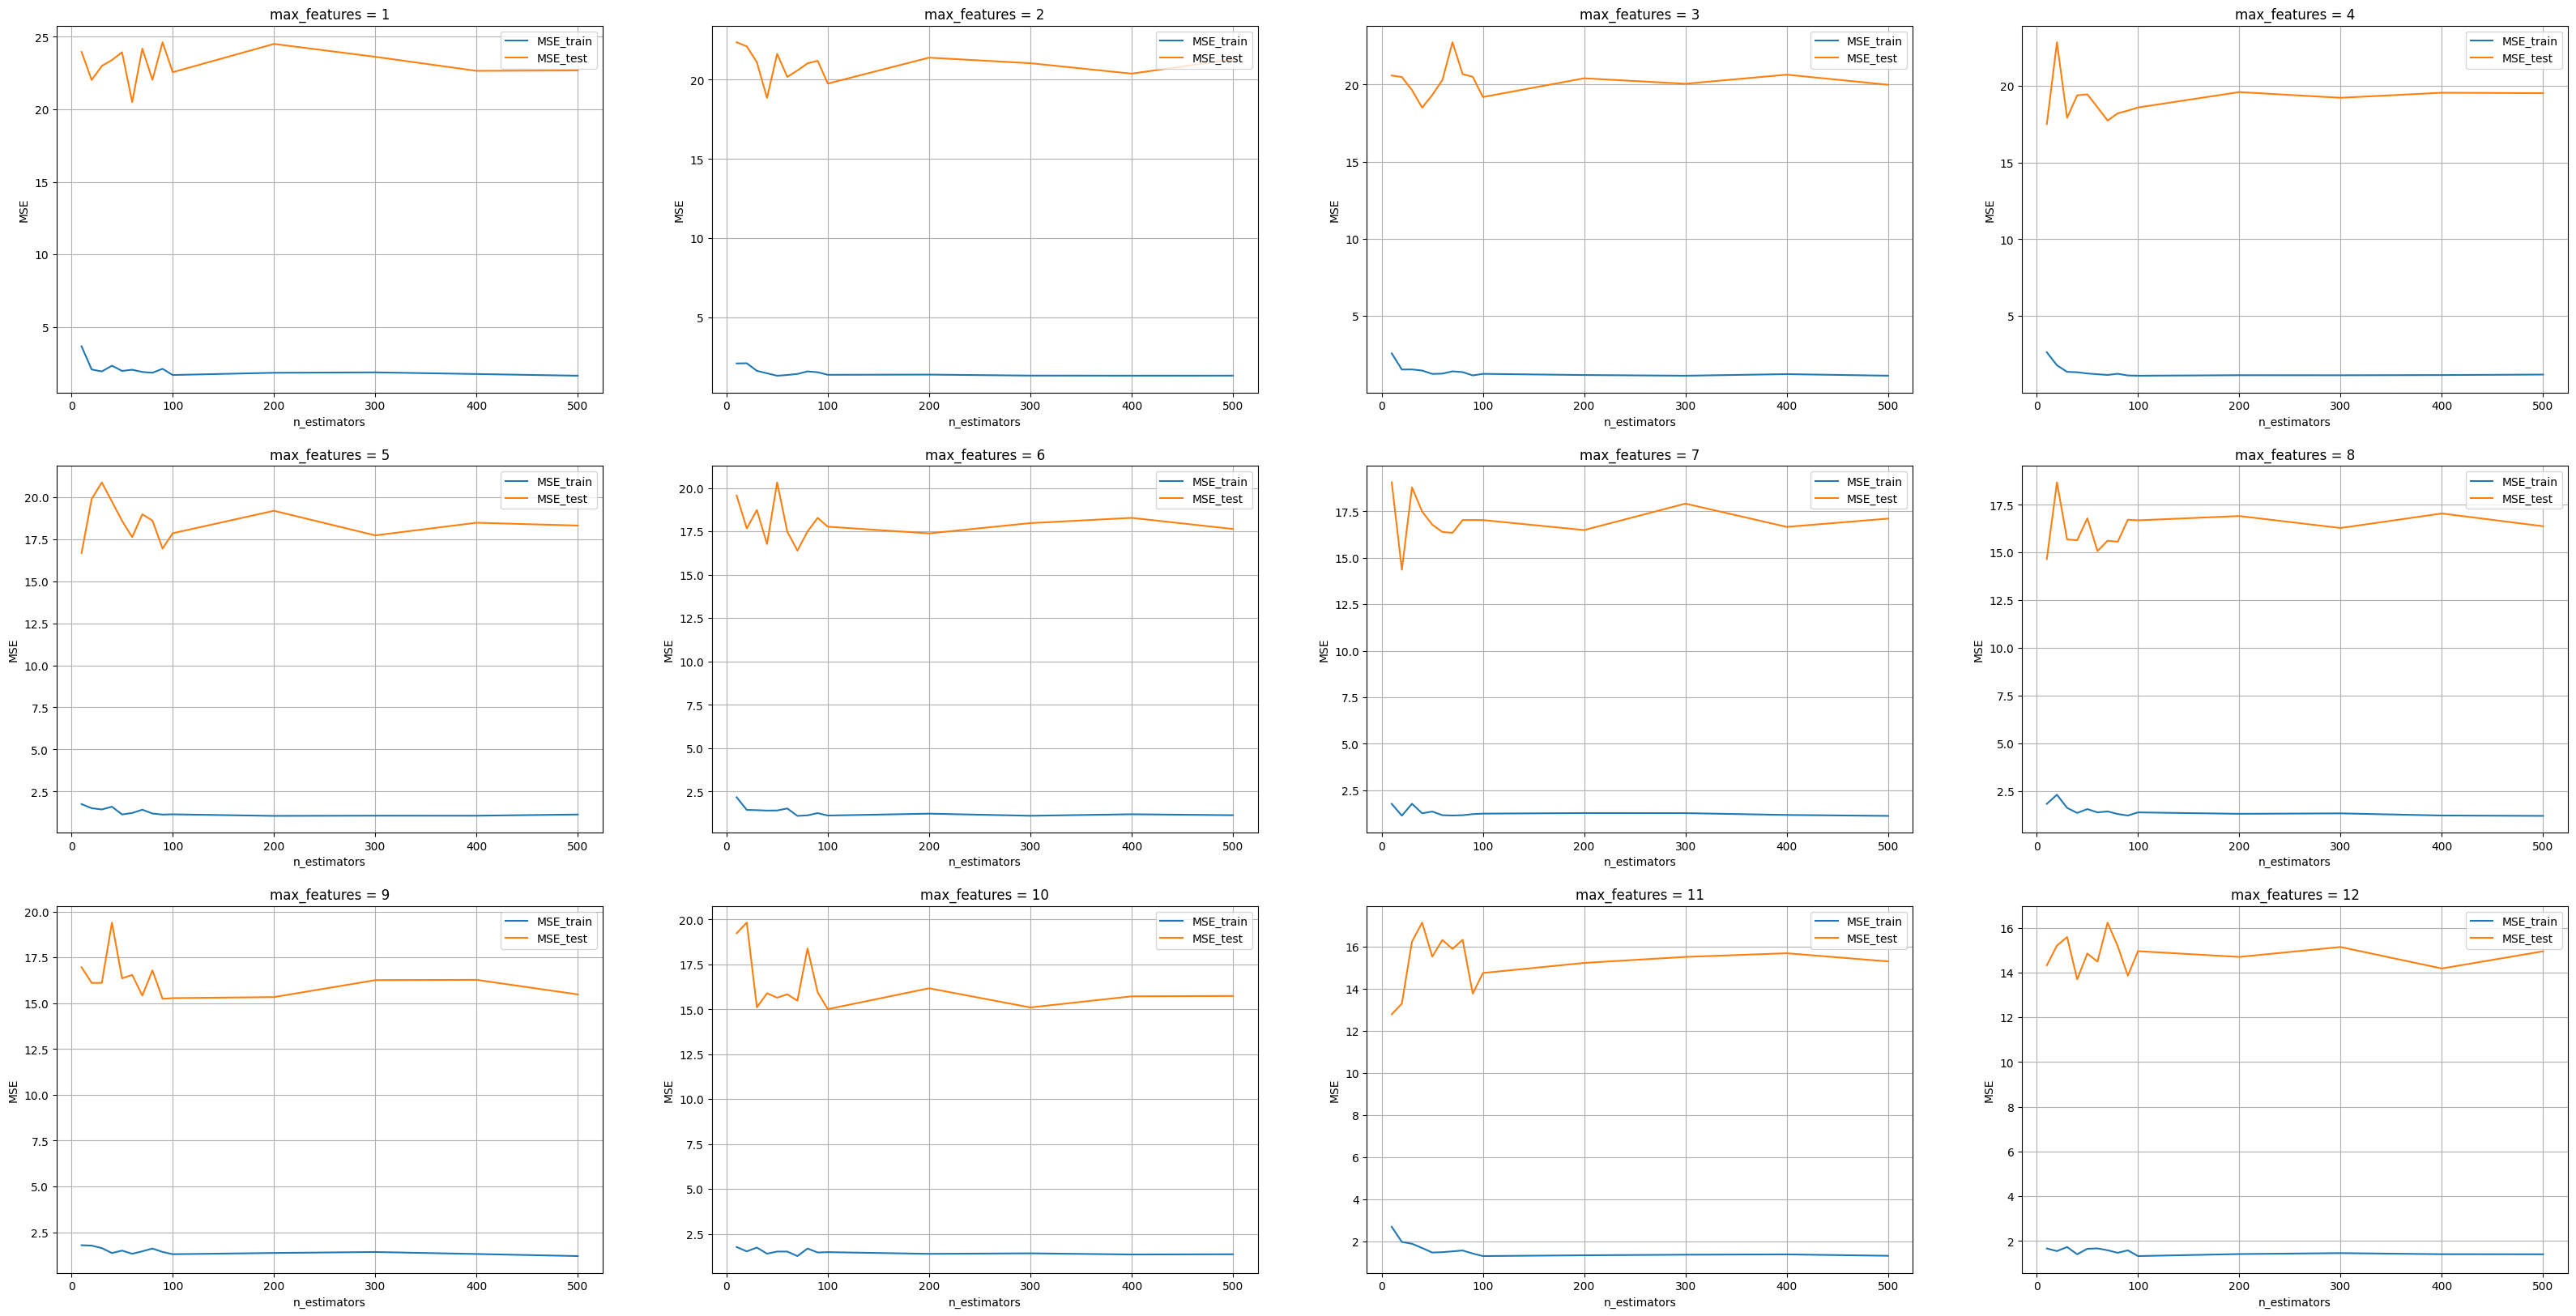

In [7]:
keys = MSE_val.keys()
fig, ax = subplots(figsize = (40,20), nrows = 3, ncols = 4)
for key in MSE_val:
    ax_cur = ax[(key-1)//4][(key-1)%4]
    
    ax_cur.plot(n_estimators_array, MSE_tr[key], label = 'MSE_train')
    ax_cur.plot(n_estimators_array, MSE_val[key], label = 'MSE_test')
    
    ax_cur.legend(loc='upper right')
    ax_cur.grid()
    ax_cur.set_title(f'max_features = {key}')
    ax_cur.set_xlabel('n_estimators')
    ax_cur.set_ylabel('MSE')

### Задание 8.

В одной из лабораторных работ мы построили дерево класификации на основе набора данных Carseats, предварительно преобразоваа отклик Sales в качественную переменную. Теперь займемся предсказанием Salse с использованием регрессионнхы деревьее и связзянных с ними подходов, восприними отклик как количестенную перменную.

(a) Разделите набор даннхы на обучающую и контрольную выборки.

In [8]:
Carseats = load_data('Carseats')
model = MS(Carseats.columns.drop('Sales'), intercept = False)
D = model.fit_transform(Carseats)
feature_names = list(D.columns)
X = np.asarray(D)

In [9]:
X_train, X_test, y_train, y_test = skm.train_test_split(X, Carseats['Sales'], test_size=0.3, random_state=0)

(b) постройте регрессионное дерево на основе обучающей выборки. Нарисуйте дерево и проинтерпретируйте полученные результаты.

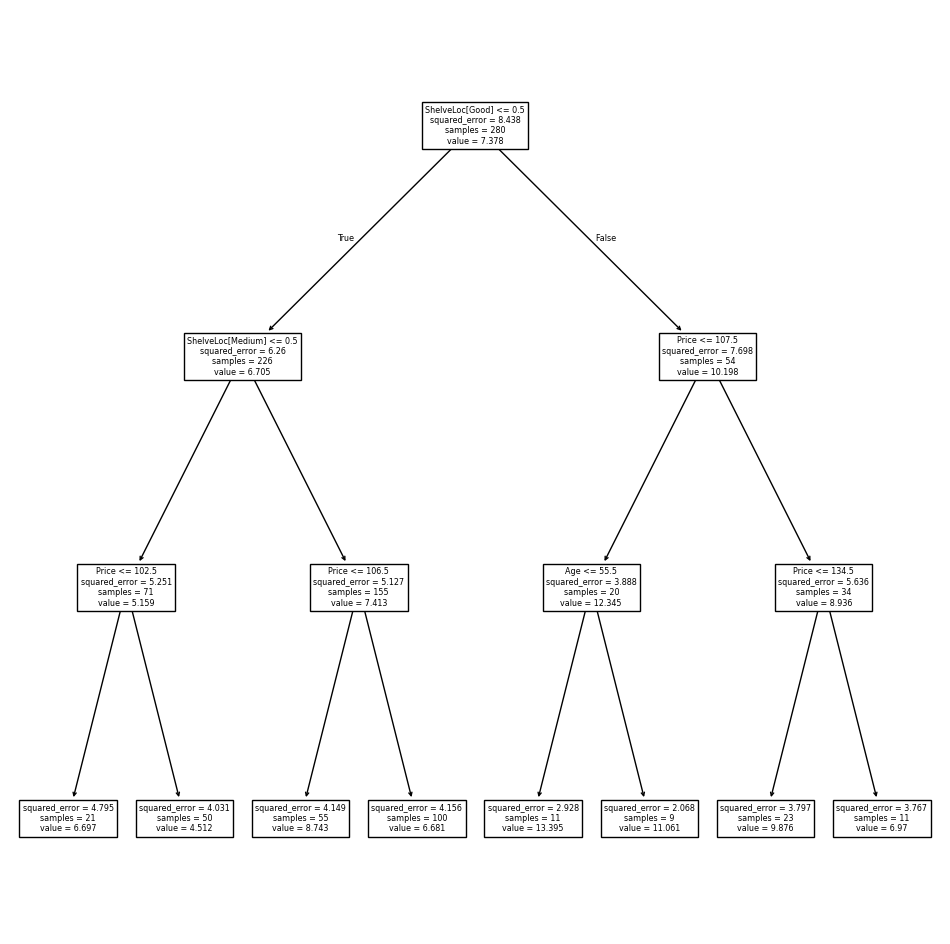

In [10]:
reg = DTR(max_depth=3)
reg.fit(X_train, y_train)
figure, ax = subplots(figsize = (12, 12))
plot_tree(reg, feature_names = feature_names, ax = ax);

In [11]:
y_hat = reg.predict(X_test)
MSE = np.mean((y_test - y_hat)**2)
print(f'MSE: {MSE}')
print(f'RMSE: {np.sqrt(MSE)}')

MSE: 3.7038582752360933
RMSE: 1.924541055741886


(c) Воспользуйтесть методо перекрестной проверки для нахождения оптимального уровня сложности дерева. Позволит ли обрезка ветвей улучшить MSE на контрольных данных?

In [12]:
ccp_path = reg.cost_complexity_pruning_path(X_train, y_train)
kfold = skm.KFold(5, shuffle = True, random_state = 10)
grid = skm.GridSearchCV(estimator = reg, param_grid={'ccp_alpha':ccp_path.ccp_alphas}, refit = True, cv = kfold, scoring = 'neg_mean_squared_error')
G = grid.fit(X_train, y_train)

In [13]:
best_ = grid.best_estimator_
y_hat = best_.predict(X_test)
print(f'MSE: {np.mean((y_test - y_hat)**2)}')

MSE: 3.7038582752360933


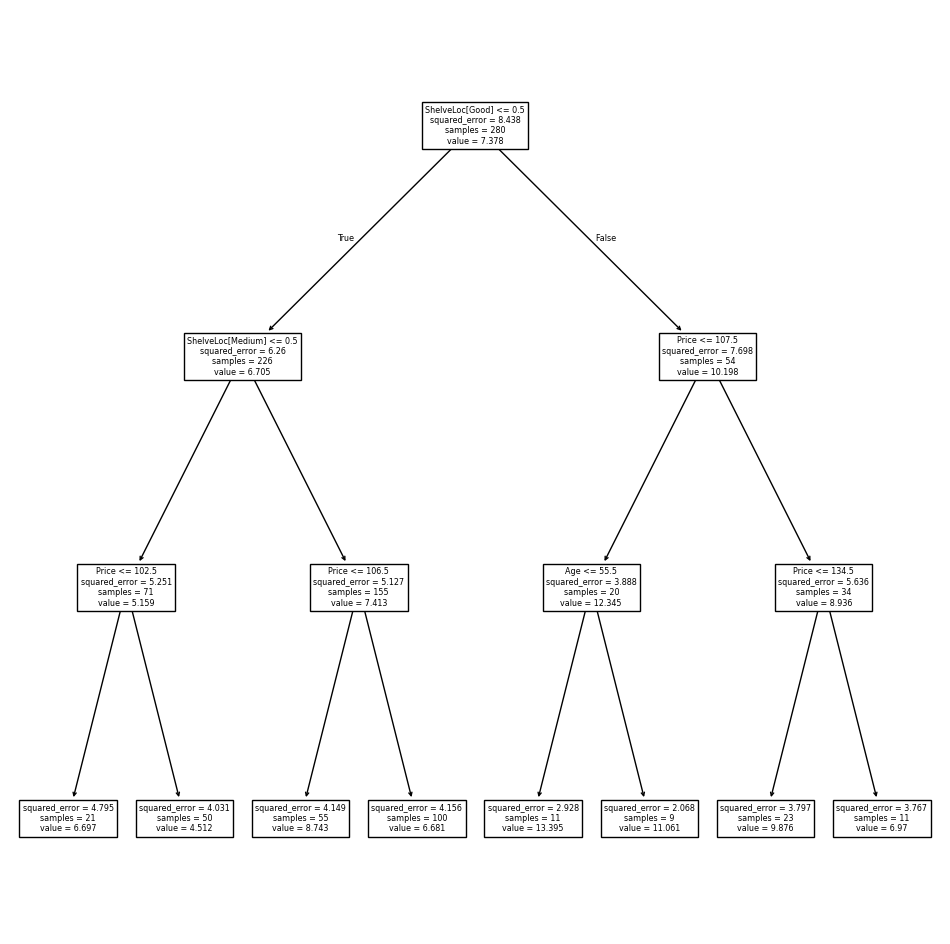

In [14]:
figure, ax = subplots(figsize = (12, 12))
plot_tree(reg, feature_names = feature_names, ax = ax);

По графику регрессионого дерева видно, что самым важным параметров для покупи сидения является замок. Вторым по важности является цена.

(d) Проанализируйте эти данные с помощью бэггинга. Кукую MSE на контрольной выборке вы получили? Воспользуйтесь значениями из feature_importance для определения того, какие перменные обладают наибольшей важностью

In [15]:
bag_carseats = RF(max_features = X_train.shape[1], random_state = 0, n_estimators=500)
bag_carseats.fit(X_train, y_train)

RandomForestRegressor(max_features=11, n_estimators=500, random_state=0)

In [16]:
y_hat = bag_carseats.predict(X_test)
print(f'MSE: {np.mean((y_test - y_hat)**2)}')

MSE: 2.0236328641333428


In [17]:
feature_imp = pd.DataFrame({'importance':bag_carseats.feature_importances_}, index = feature_names)
feature_imp.sort_values(by='importance', ascending=False)

,importance
Price,0.286600
ShelveLoc[Good],0.220007
Age,0.105353
CompPrice,0.100679
ShelveLoc[Medium],0.085092
Advertising,0.068876
Income,0.053628
Population,0.039242
Education,0.029639
US[Yes],0.006542


Бэккинг в отличие от регрисионного дерева выделил цену, как самый важные признак. Вторым по важности признаком является замок сидения.

(e) Проинализируйте эти данные с помощью метода случайного леса. Какую MSE на котрольной выборке вы получили? Воспользуйтесь значениями из feature_importance_ для определения того, какие переменные обладают наибольшей важностью.

In [18]:
MSE_val = dict()
MSE_tr = dict()

max_features_array = [i for i in range(1, 7)]
n_estimators_array = [i*100 for i in range(1, 9)]

best_rnd_forest = None
best_MSE = float('inf')

for max_features in max_features_array:
    for n_estimators in n_estimators_array:
        rnd_forest = RF(max_depth = max_features, n_estimators = n_estimators).fit(X_train, y_train)

        y_hat_train = rnd_forest.predict(X_train)
        y_hat_test = rnd_forest.predict(X_test)
        
        MSE_train = np.mean((y_train - y_hat_train)**2)
        MSE_test = np.mean((y_test - y_hat_test)**2)

        MSE_tr[max_features] = MSE_tr.get(max_features, []) + [MSE_train]
        MSE_val[max_features] = MSE_val.get(max_features, []) + [MSE_test]
        
        if MSE_test < best_MSE:
            best_MSE = MSE
            best_rnd_forest = rnd_forest



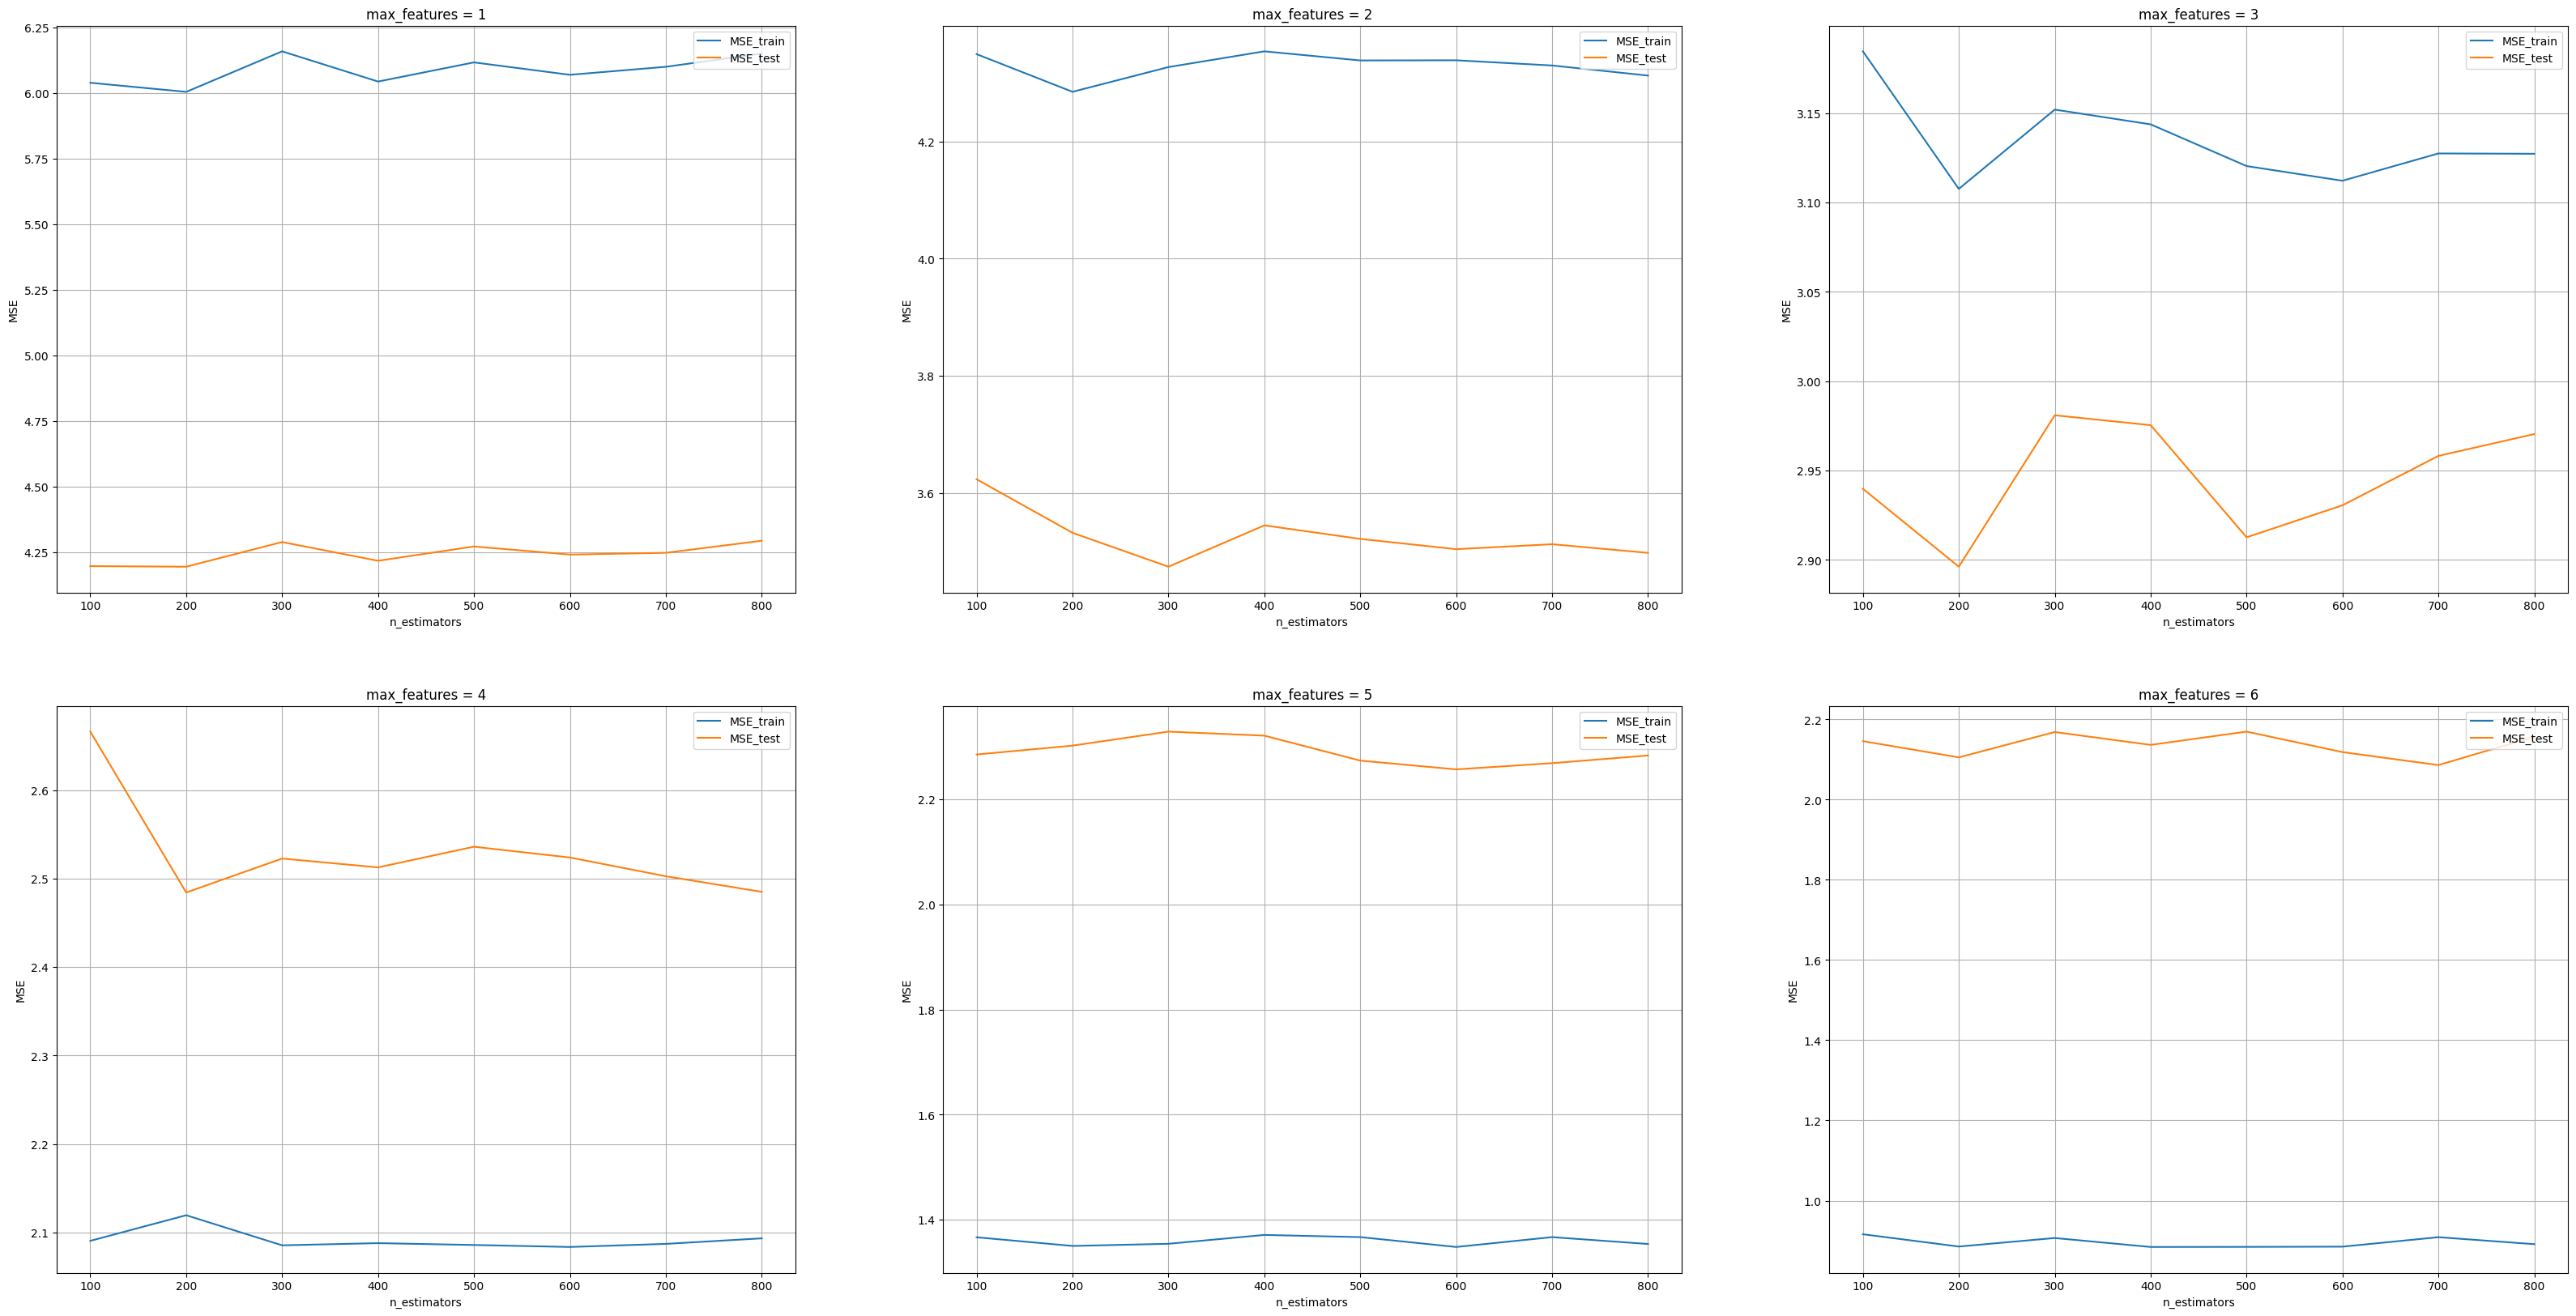

In [19]:
keys = MSE_val.keys()
fig, ax = subplots(figsize = (40,20), nrows = 2, ncols = 3)
for key in MSE_val:
    ax_cur = ax[(key-1)//3][(key-1)%3]
    
    ax_cur.plot(n_estimators_array, MSE_tr[key], label = 'MSE_train')
    ax_cur.plot(n_estimators_array, MSE_val[key], label = 'MSE_test')
    
    ax_cur.legend(loc='upper right')
    ax_cur.grid()
    ax_cur.set_title(f'max_features = {key}')
    ax_cur.set_xlabel('n_estimators')
    ax_cur.set_ylabel('MSE')

In [20]:
feature_imp = pd.DataFrame({'importance':best_rnd_forest.feature_importances_}, index = feature_names)
feature_imp.sort_values(by='importance', ascending=False)

,importance
Price,0.300835
ShelveLoc[Good],0.247534
Age,0.097055
ShelveLoc[Medium],0.093937
CompPrice,0.091329
Advertising,0.065541
Income,0.044296
Population,0.029419
Education,0.021380
US[Yes],0.005928


Случайный лес выдели цену как самый важный признак, вторым по важности признаком является замок сидения.

(f) Теперь проанализируйте данные с помощью метода BART и сообщите о результатах.

In [21]:
bart_carseats = BART(random_state = 0, burnin = 5, ndraw=15)
bart_carseats.fit(X_train, y_train)

BART(burnin=5, ndraw=15, random_state=0)

In [22]:
y_hat = bag_carseats.predict(X_test.astype(np.float32))
print(f'MSE: {np.mean((y_test - y_hat)**2)}')

MSE: 2.0236328641333428


In [23]:
feature_imp = pd.DataFrame({'importance':bart_carseats.variable_inclusion_.mean(0)}, index = feature_names)
feature_imp.sort_values(by='importance', ascending=False)

,importance
Price,34.266667
Age,33.733333
ShelveLoc[Good],33.266667
CompPrice,29.600000
ShelveLoc[Medium],27.266667
Advertising,27.200000
US[Yes],26.400000
Population,25.866667
Urban[Yes],25.800000
Education,24.200000


Bart цену как самый важный признак, вторым по важности признаком является возраст сидения.

### Задание 9.

В этом упражнении мы поработаем с набором данных OJ, входящим в состав пакеты ISLP.

(a) Создайте обучающую выборку на основе 800 случайно выбранных наблюдений, а оставшиесмя наблюдения отнесите к контрольной выборке.

In [24]:
OJ = load_data('OJ')
model = MS(OJ.columns.drop('Purchase'), intercept = False)
D = model.fit_transform(OJ)
feature_names = list(D.columns)
X = np.asarray(D)

In [25]:
X_train, X_test, y_train, y_test = skm.train_test_split(X, OJ['Purchase'], test_size=0.3, random_state=0)

(b) Постройте дерево на основе обучающих данных с перменной Purchase в качестве отклика и остальными перменными в качетве предикторов. Какую частоту ошибк на обучающих данных вы получили?

In [26]:
DTC_OJ = DTC(max_depth = 3)
DTC_OJ.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

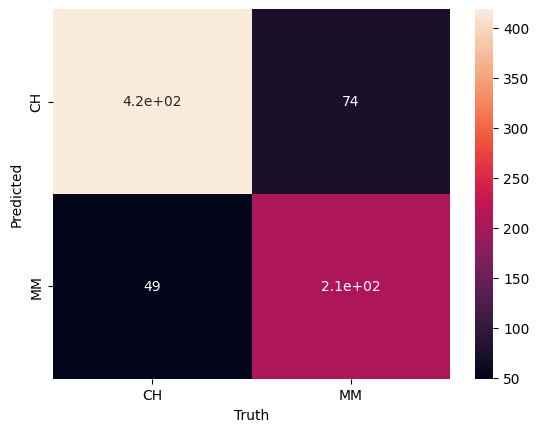

In [27]:
y_hat = DTC_OJ.predict(X_train)
confusion = confusion_table(y_hat, y_train)
sns.heatmap(confusion, annot = True);

In [28]:
confusion

Truth,CH,MM
Predicted,,
CH,419,74
MM,49,207


In [29]:
print(classification_report(y_train, y_hat))

              precision    recall  f1-score   support

          CH       0.85      0.90      0.87       468
          MM       0.81      0.74      0.77       281

    accuracy                           0.84       749
   macro avg       0.83      0.82      0.82       749
weighted avg       0.83      0.84      0.83       749



(c) Изобразите дерево на графике.

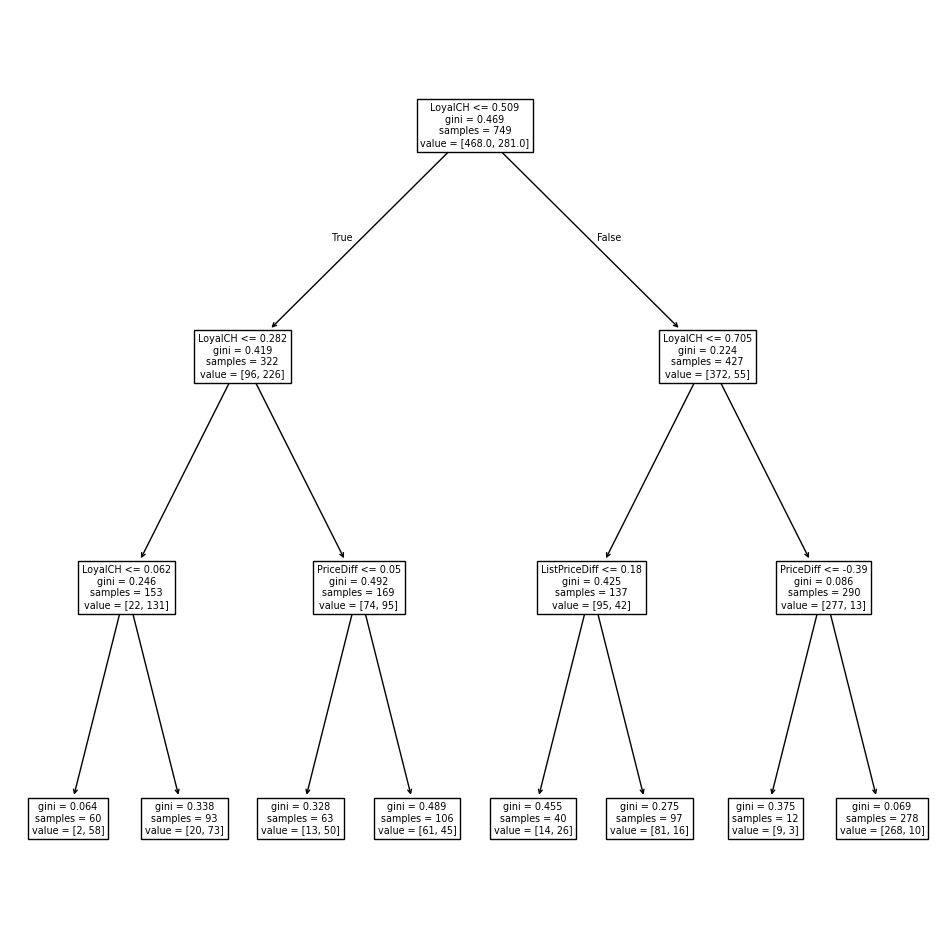

In [30]:
fig, ax = subplots(figsize = (12, 12))
plot_tree(DTC_OJ, feature_names = feature_names, ax= ax);

(d) Воспользуйтесь функцией export_tree() для выввода текстового представления дерева.

In [31]:
print(export_text(DTC_OJ, feature_names = feature_names, show_weights=True))

|--- LoyalCH <= 0.51
|   |--- LoyalCH <= 0.28
|   |   |--- LoyalCH <= 0.06
|   |   |   |--- weights: [2.00, 58.00] class: MM
|   |   |--- LoyalCH >  0.06
|   |   |   |--- weights: [20.00, 73.00] class: MM
|   |--- LoyalCH >  0.28
|   |   |--- PriceDiff <= 0.05
|   |   |   |--- weights: [13.00, 50.00] class: MM
|   |   |--- PriceDiff >  0.05
|   |   |   |--- weights: [61.00, 45.00] class: CH
|--- LoyalCH >  0.51
|   |--- LoyalCH <= 0.71
|   |   |--- ListPriceDiff <= 0.18
|   |   |   |--- weights: [14.00, 26.00] class: MM
|   |   |--- ListPriceDiff >  0.18
|   |   |   |--- weights: [81.00, 16.00] class: CH
|   |--- LoyalCH >  0.71
|   |   |--- PriceDiff <= -0.39
|   |   |   |--- weights: [9.00, 3.00] class: CH
|   |   |--- PriceDiff >  -0.39
|   |   |   |--- weights: [268.00, 10.00] class: CH



(e) Выполните предсказание отклика на контрольнхы даннхы и постройте матрицу неточностей. Какую частоту ошибку вы получили?

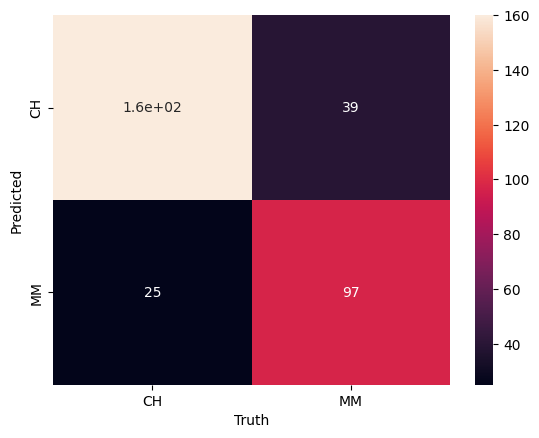

In [32]:
y_hat = DTC_OJ.predict(X_test)
confusion = confusion_table(y_hat, y_test)
sns.heatmap(confusion, annot = True);

In [33]:
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

          CH       0.80      0.86      0.83       185
          MM       0.80      0.71      0.75       136

    accuracy                           0.80       321
   macro avg       0.80      0.79      0.79       321
weighted avg       0.80      0.80      0.80       321



Наша модель классифицирует 80% обучающих данных правильно.

(f) Воспользуйтесть методо перекрестной проверки на обучающей выборке для определение оптимального размера дерева.

In [34]:
kfold = skm.KFold(5, shuffle = True, random_state = 10)
param_grid = {'max_depth': [i for i in range(1, 8)]}
grid = skm.GridSearchCV(estimator = DTC_OJ, param_grid=param_grid, refit = True, cv = kfold, scoring = 'accuracy')
G = grid.fit(X_train, y_train)

(g) Выведите график с размерами деревьек на осни x и частотой ошибок классификации на основе перекрестной проверки на осни y.

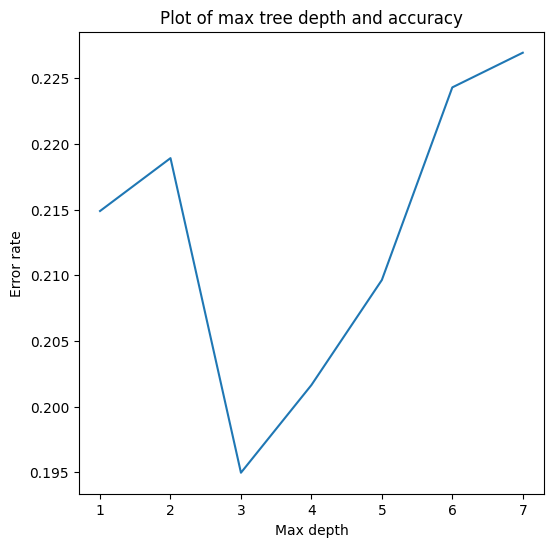

In [35]:
cv_results = pd.DataFrame(G.cv_results_)

fig, ax = subplots(figsize = (6,6))
ax.plot(param_grid['max_depth'], 1 - cv_results['mean_test_score'])
ax.set_title('Plot of max tree depth and accuracy')
ax.set_xlabel('Max depth')
ax.set_ylabel('Error rate');

(h) Какой размер дерева соотвесттвуте наимешьшей частоте ошибок классификации на основе перекрестной проверки?

In [36]:
clf = DTC(max_depth = 5, random_state = 0, criterion='entropy')
clf.fit(X_train, y_train)
accuracy_score(y_test, clf.predict(X_test))

0.778816199376947

In [37]:
cpp_path = clf.cost_complexity_pruning_path(X_train, y_train)
kfold = skm.KFold(5, random_state=0, shuffle = True)

In [38]:
grid = skm.GridSearchCV(estimator = clf, param_grid={'ccp_alpha':ccp_path.ccp_alphas}, refit = True, cv = kfold, scoring = 'accuracy')
G = grid.fit(X_train, y_train)

In [39]:
G.best_score_

0.787695749440716

In [40]:
G.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)

(j) Сравните чстоты ошибк на обучающих даднных для обрезанного и необрезанного деревьев. Какая из них выше?

In [41]:
print('DecisonTreeClassifier:', 1 - accuracy_score(y_train, clf.predict(X_train)))
print('PuredngDecisionTreeClassifier test Accuracy:', 1 - accuracy_score(y_train, G.predict(X_train)))

DecisonTreeClassifier: 0.144192256341789
PuredngDecisionTreeClassifier test Accuracy: 0.144192256341789


(k) Срваните частоты ошибк на контрольных данных для обрезанного и необрезанного деревьев. Какая из них выше?

In [42]:
print('DecisonTreeClassifier:', 1 - accuracy_score(y_test, clf.predict(X_test)))
print('PuredngDecisionTreeClassifier test Accuracy:', 1 - accuracy_score(y_test, G.predict(X_test)))

DecisonTreeClassifier: 0.22118380062305298
PuredngDecisionTreeClassifier test Accuracy: 0.22118380062305298


### Задание 10.

Теперь мы восопльзуемся бустингом для предсказания откилка Salary в наборе дыннхы Hitters.

(a) Удалите наблюдения, для которых данные по зарплате остустсвуют, после чего примените логорифмическое преобразование к оставшимся значениям этой переменной.

In [43]:
hitter = load_data('Hitters')
hitter = hitter.dropna()
hitter['Salary'] = np.log(hitter['Salary'])
hitter = pd.get_dummies(hitter, drop_first = True)

(b) Создайте обучающей выборку на оснвое 200 первых наблюдений, а оставшиеся наблюдения отнесите к контрольной выборке.

In [44]:
hitter_train = hitter.iloc[1:202]
hitter_test = hitter.iloc[202:]

X_train, y_train, X_test, y_test = hitter_train.drop(labels = 'Salary', axis = 1), hitter_train['Salary'], hitter_test.drop(labels = 'Salary', axis = 1), hitter_test['Salary']

(c) Примените метод бустинга на обучающих дыннх из 1000 деревье для интервала значений параметрка $\lambda$. Постройте график, в котором на оси x будут располагаться значения $\lambda$, а на оси y - MSE на обучающих данных.

In [45]:
boost_salary = GBR(n_estimators=1000, max_depth = 3, random_state = 0)
kfold = skm.KFold(5, shuffle = True, random_state = 10)

param_grid = {'learning_rate': [0.001*(10**i) for i in range(0, 5)]}
grid = skm.GridSearchCV(boost_salary, param_grid = param_grid, cv = kfold, refit = True, scoring = 'neg_mean_squared_error')
G = grid.fit(X_train, y_train)

C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\ensemble\_gb.py:262: RuntimeWarning: invalid value encountered in add
  raw_prediction[:, k] += learning_rate * tree.value[:, 0, 0].take(
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\model_selection\_validation.py:982: UserWarning: Scoring failed. The sco

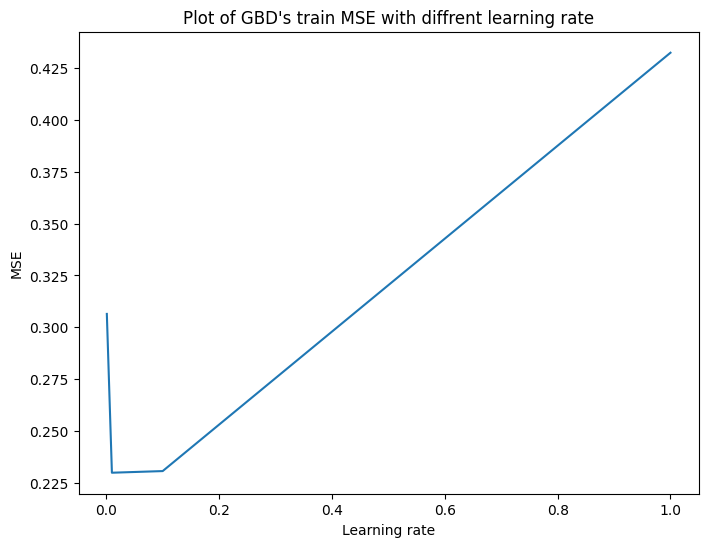

In [46]:
cv_results = pd.DataFrame(G.cv_results_)

fix, ax = subplots(figsize = (8, 6))

ax.set_title("Plot of GBD's train MSE with diffrent learning rate")
ax.set_xlabel('Learning rate')
ax.set_ylabel('MSE')
ax.plot(param_grid['learning_rate'], -cv_results['mean_test_score']);

(c) Постройте график, в котором на оси x будут располагаться занчеия $\lambda$, а на оси y - MSE на контрольных данных.

In [47]:
kfold = skm.KFold(5, shuffle = True, random_state = 10)
params = [0.01*(10**i) for i in range(0, 5)]
MSE_test = []
print(params)
for p in params:
    boost_salary = GBR(n_estimators=1000, max_depth = 3, random_state = 0, learning_rate=p).fit(X_train, y_train)
    MSE_test.append(np.mean((y_test - boost_salary.predict(X_test))**2))
    

[0.01, 0.1, 1.0, 10.0, 100.0]


C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\ensemble\_gb.py:262: RuntimeWarning: invalid value encountered in add
  raw_prediction[:, k] += learning_rate * tree.value[:, 0, 0].take(
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\ensemble\_gb.py:262: RuntimeWarning: overflow encountered in multiply
  

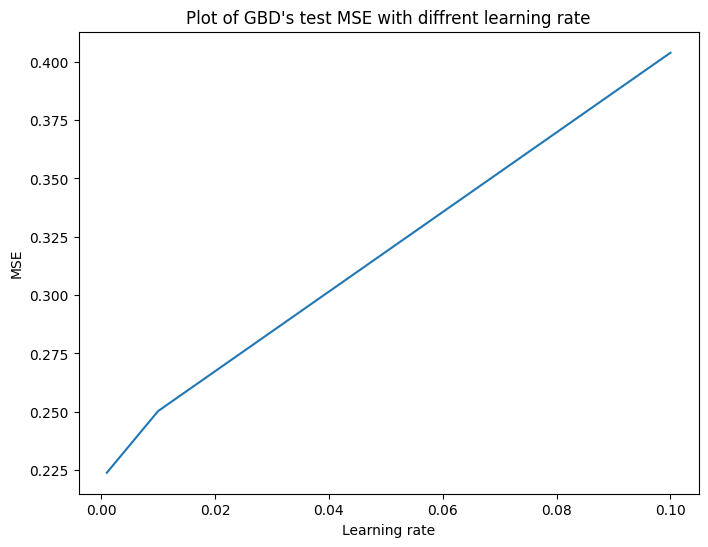

In [48]:
fix, ax = subplots(figsize = (8, 6))

ax.set_title("Plot of GBD's test MSE with diffrent learning rate")
ax.set_xlabel('Learning rate')
ax.set_ylabel('MSE')
ax.plot(param_grid['learning_rate'], MSE_test);